Libraries imported
Dataset Loaded

First 5 rows:
     0.02  0.0371  0.0428  0.0207  0.0954  0.0986  0.1539  0.1601  0.3109  \
0  0.0453  0.0523  0.0843  0.0689  0.1183  0.2583  0.2156  0.3481  0.3337   
1  0.0262  0.0582  0.1099  0.1083  0.0974  0.2280  0.2431  0.3771  0.5598   
2  0.0100  0.0171  0.0623  0.0205  0.0205  0.0368  0.1098  0.1276  0.0598   
3  0.0762  0.0666  0.0481  0.0394  0.0590  0.0649  0.1209  0.2467  0.3564   
4  0.0286  0.0453  0.0277  0.0174  0.0384  0.0990  0.1201  0.1833  0.2105   

   0.2111  ...  0.0027  0.0065  0.0159  0.0072  0.0167   0.018  0.0084  \
0  0.2872  ...  0.0084  0.0089  0.0048  0.0094  0.0191  0.0140  0.0049   
1  0.6194  ...  0.0232  0.0166  0.0095  0.0180  0.0244  0.0316  0.0164   
2  0.1264  ...  0.0121  0.0036  0.0150  0.0085  0.0073  0.0050  0.0044   
3  0.4459  ...  0.0031  0.0054  0.0105  0.0110  0.0015  0.0072  0.0048   
4  0.3039  ...  0.0045  0.0014  0.0038  0.0013  0.0089  0.0057  0.0027   

    0.009  0.0032  R  
0  0.0052  0.0044  R

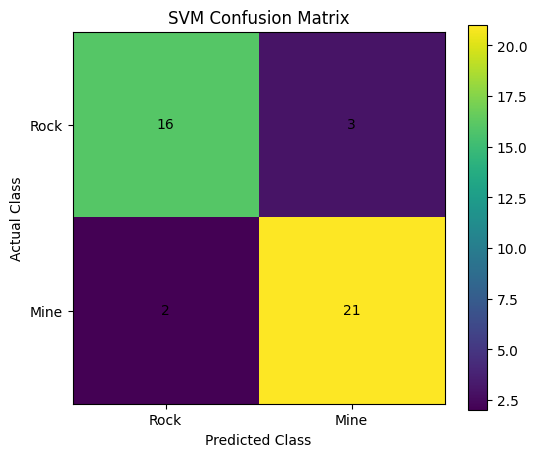

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Libraries imported")

# Load Sonar dataset
dataset = pd.read_csv("/content/sonar.csv")

print("Dataset Loaded")

print("\nFirst 5 rows:")
print(dataset.head())

print("\nDataset Shape:")
print(dataset.shape)

# Separate features and target
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

print("\nFeatures:")
print(X[:5])

print("\nTarget:")
print(y[:5])

# Convert target labels into binary values
y = np.where(y == 'M', 1, 0)

print("\nEncoded Target:")
print(y[:10])

# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

print("\nTraining Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

# Standardize the data
sc = StandardScaler()

X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

print("\nData Standardized")

# Create SVM model
svm_model = SVC()

# Parameters for optimization
parameters = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

# Grid Search for best parameters
grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=parameters,
    cv=5,
    scoring='accuracy'
)

# Train and optimize SVM
grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(grid_search.best_score_)

# Get best SVM model
model = grid_search.best_estimator_

print("\nBest SVM Model:")
print(model)

# Prediction on test data
y_pred = model.predict(X_test)

print("\nPredicted Test Results:")
print(y_pred)

print("\nActual Test Results:")
print(y_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(accuracy * 100, "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Rock', 'Mine']
    )
)

# Test model score
model_score = model.score(X_test, y_test)

print("\nModel Test Score:")
print(model_score)

# Visualize Confusion Matrix
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("SVM Confusion Matrix")

plt.xlabel("Predicted Class")

plt.ylabel("Actual Class")

plt.xticks([0, 1], ['Rock', 'Mine'])

plt.yticks([0, 1], ['Rock', 'Mine'])

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()